## Test ensemble HBV

### ToDo
- automate in .py?
- fix links to forcing and shapefiles etc
- auto delete files

In [1]:
# General python
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

# fiona
import fiona
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.geometry
import xarray as xr
from pyproj import Geod

# Niceties
from rich import print

# progressbar
from tqdm.notebook import tqdm

In [2]:
# The name of the shapefile
shape_file_name = "GRDC_Kerki"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1990-01-01T00:00:00Z"
experiment_end_date = "1995-12-31T00:00:00Z"

forcing_path_ERA5 = (
    Path.home()
    / "MSc_AralSea"
    / "book"
    / "thesis_projects"
    / "MSc"
    / "2025_Q1_AndreVanDerVeen_CEG"
    / "work_in_progress"
    / "forcing"
    / "output"
    / "forcing_HBV_ERA5_GRDC_Kerki_5456"
    / shape_file_name
    / "ERA5"
    / "own_shapefile"
)


load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

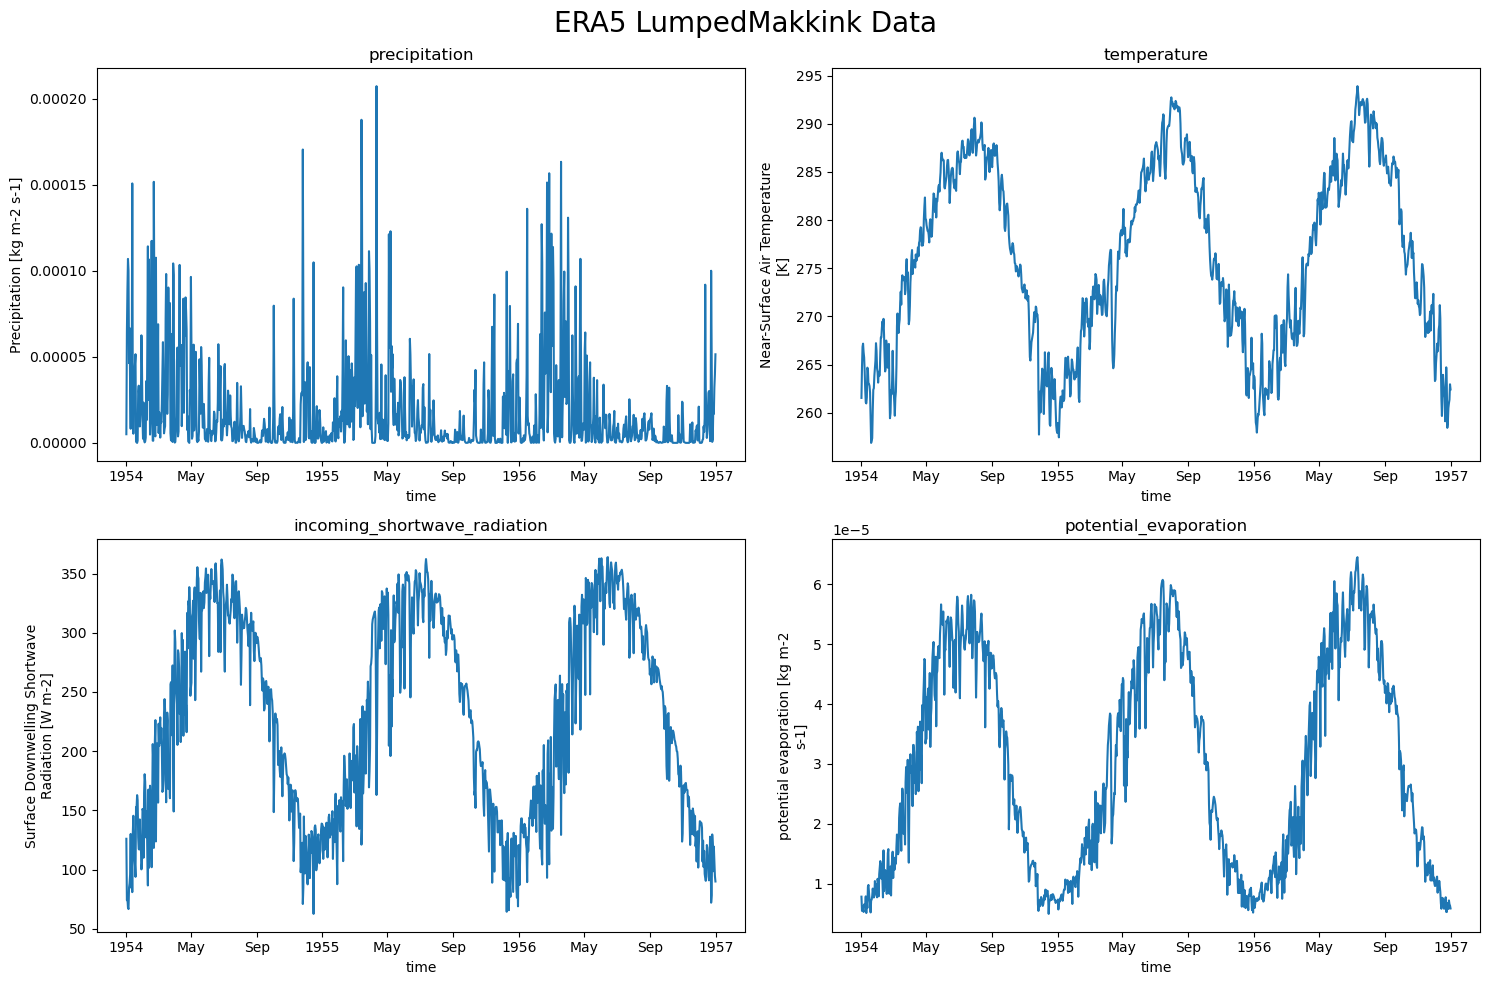

In [3]:
ERA5_data = {
    "precipitation pr": xr.open_dataset(ERA5_forcing["pr"]),
    "temperature tas": xr.open_dataset(ERA5_forcing["tas"]),
    "incoming_shortwave_radiation rsds": xr.open_dataset(ERA5_forcing["rsds"]),
    "potential_evaporation evspsblpot": xr.open_dataset(ERA5_forcing["evspsblpot"]),
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2, 2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

In [4]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(
    2617110,
    "1954-01-01T00:00Z",
    "1956-12-31T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)

In [5]:
n_particles = 100

In [6]:
## Array of initial storage terms - we keep these constant for now
##              Si,  Su, Sf, Ss
s_0 = np.array([0, 100, 0, 5, 0])

## Array of parameters min/max bounds as a reference
##                      Imax,  Ce,  Sumax, beta,  Pmax,  T_lag,   Kf,   Ks,    Fm
parameter_set_fromsomewhere = [
    7.085,  # Imax
    0.837,  # Ce
    76.373,  # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226,  # FM
]


param_array = np.array(parameter_set_fromsomewhere)
# p_min_initial = np.array(parameter_set_fromsomewhere) * [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.5]
# p_max_initial = np.array(parameter_set_fromsomewhere) * [1.5, 2.5, 1.5, 1.5, 1.5, 5, 2, 2, 1.5]
##                      Imax,  Ce,   Sumax,  beta,   Pmax,   T_lag,    Kf,    Ks,     Fm
# p_min_initial=  0.3 * param_array #np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
# p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
p_min_initial = np.array([0, 0.2, 40, 0.5, 0.001, 1, 0.01, 0.0001, 0.01])
p_max_initial = np.array([25, 1, 800, 4, 0.3, 15, 0.02, 0.01, 0.4])
# p_max_initial =np.array([25,    1,  800,   4,    .3,     80,    .1,   .01,      1])
# p_max_initial = 10 * param_array #np.array(10*parameter_set_fromsomewhere) # np.array([25,    1,  800,   4,    .3,     100,    .1,   .01,      1])
array_random_num = np.array(
    [[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)]
)
p_initial = p_min_initial + array_random_num * (p_max_initial - p_min_initial)


p_names = ["$I_{max}$", "$C_e$", "$Su_{max}$", "β", "$P_{max}$", "$T_{lag}$", "$K_f$", "$K_s$"]
S_names = [
    "Interception storage",
    "Unsaturated Rootzone Storage",
    "Fastflow storage",
    "Groundwater storage",
]
param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
stor_names = ["Si", "Su", "Sf", "Ss", "Sp"]

# set initial as mean of max,min
# par_0 = (p_min_initial + p_max_initial)/2

In [7]:
array_random_num = np.array(
    [[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)]
)
p_initial = p_min_initial + array_random_num * (p_max_initial - p_min_initial)

In [8]:
all_discharges = []
all_param_values = []


for i in tqdm(range(n_particles), desc="Running HBV experiments"):
    params = dict(zip(param_names, p_initial[i]))
    params_array = p_initial[i]

    model = ewatercycle.models.HBV(forcing=ERA5_forcing)

    cfg_file, _ = model.setup(parameters=params_array, initial_storage=s_0)
    model.initialize(cfg_file)

    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])  # punt-HBV, 1-element array
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Q per timestep
    discharge_da = xr.DataArray(Q_m, coords={"time": time}, dims=["time"])
    discharge_da = discharge_da.expand_dims("particle").assign_coords(particle=[i])
    all_discharges.append(discharge_da)

    # parameters as DataArray
    param_da = xr.DataArray(p_initial[i], coords={"parameter": param_names}, dims=["parameter"])
    param_da = param_da.expand_dims("particle").assign_coords(particle=[i])
    all_param_values.append(param_da)

# combine data arrays
discharge_ensemble = xr.concat(all_discharges, dim="particle")
param_array = xr.concat(all_param_values, dim="particle")

Running HBV experiments:   0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
discharge_ensemble

<xarray.DataArray (particle: 100, time: 1095)> Size: 876kB
array([[0.000394  , 0.00157481, 0.00354005, ..., 0.02244161, 0.02220603,
        0.02197348],
       [0.00132429, 0.0053004 , 0.01193471, ..., 0.02735961, 0.02729949,
        0.02723932],
       [0.00400088, 0.01603389, 0.03415865, ..., 0.17769787, 0.17518242,
        0.17270638],
       ...,
       [0.00091505, 0.00183381, 0.00184122, ..., 0.0303278 , 0.03005866,
        0.02979256],
       [0.00049661, 0.00201606, 0.00461703, ..., 0.1050123 , 0.10403532,
        0.10306917],
       [0.00042766, 0.00170978, 0.00384461, ..., 0.05579564, 0.05546006,
        0.05512977]])
Coordinates:
  * time      (time) datetime64[ns] 9kB 1954-01-02T12:00:00 ... 1956-12-31T12...
  * particle  (particle) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99

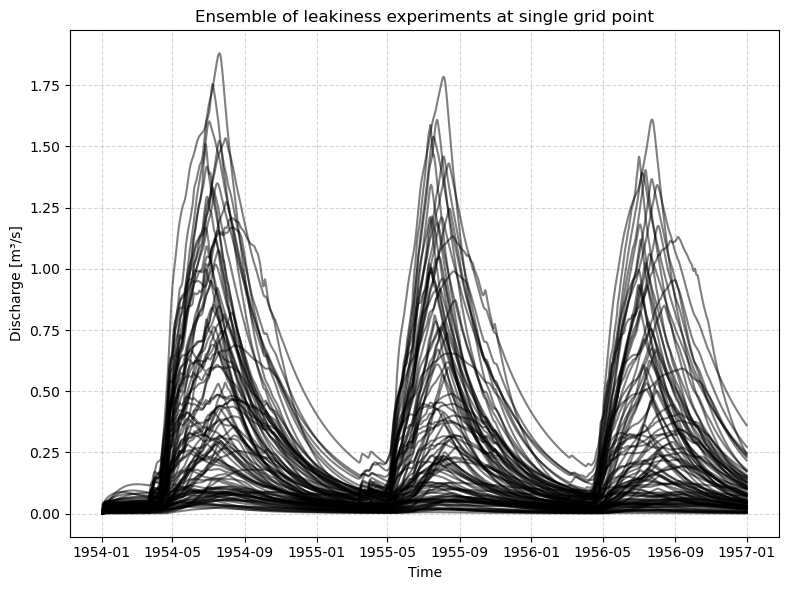

In [10]:
discharge_1955 = discharge_ensemble.sel(time=slice("1954-01-01", "1956-12-31"))


plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_1955.particle.values):
    plt.plot(
        discharge_1955.time,
        discharge_1955.isel(particle=i),
        label=f"leakiness={leak:.2f}",
        color="black",
        alpha=0.5,
    )

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of leakiness experiments at single grid point")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [12]:
area_Kerki = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Kerki/GRDC_Kerki.shp"
)
conversion_mmday2m3s = 1 / (1000 * 86400)

conversion_factor = conversion_mmday2m3s * area_Kerki

In [13]:
discharge_m3s = discharge_ensemble * conversion_factor

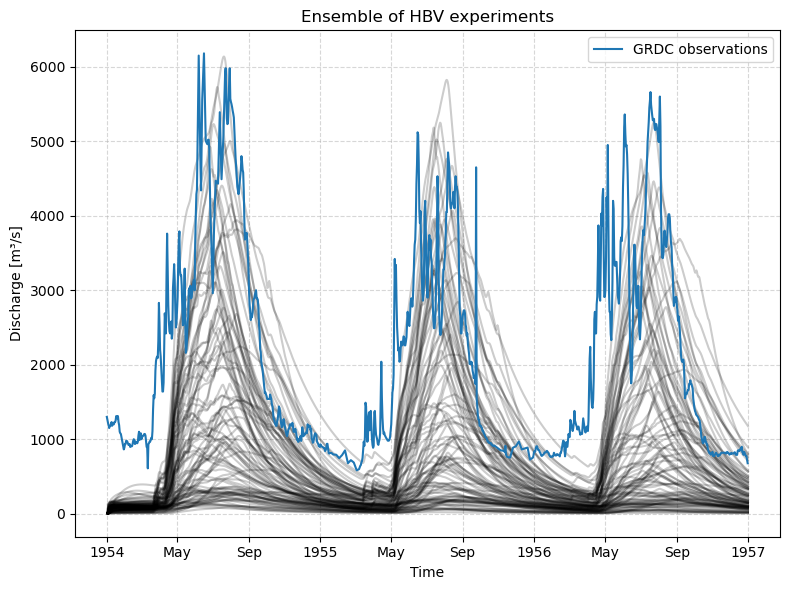

In [15]:
discharge_1955_m3 = discharge_m3s.sel(time=slice("1954-01-01", "1956-12-31"))


plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_1955_m3.particle.values):
    plt.plot(
        discharge_1955_m3.time,
        discharge_1955_m3.isel(particle=i),
        # label=f"particle {leak}",
        color="black",
        alpha=0.2,
    )


# plot GRDC
max_y = 2 * ds["streamflow"].max()
ds["streamflow"].plot(label="GRDC observations")

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [19]:
discharge_ensemble.to_netcdf("HBV_Kerki_ensamble_5456_mmd.nc")
discharge_m3s.to_netcdf("HBV_Kerki_ensamble_5456_m3s.nc")
param_array.to_netcdf("HBV_Kerki_ensamble_5456_params.nc")

In [20]:
# max per particle
max_per_particle = discharge_1955_m3.max(dim="time")  # DataArray met dim particle

# particle met hoogste max
particle_idx = max_per_particle.argmax().item()  # geeft de index van particle

# hoogste waarde
highest_discharge = max_per_particle.max().item()

print(f"Particle {particle_idx} heeft de hoogste max discharge: {highest_discharge}")

Particle 74 heeft de hoogste max discharge: 6135.971891488487

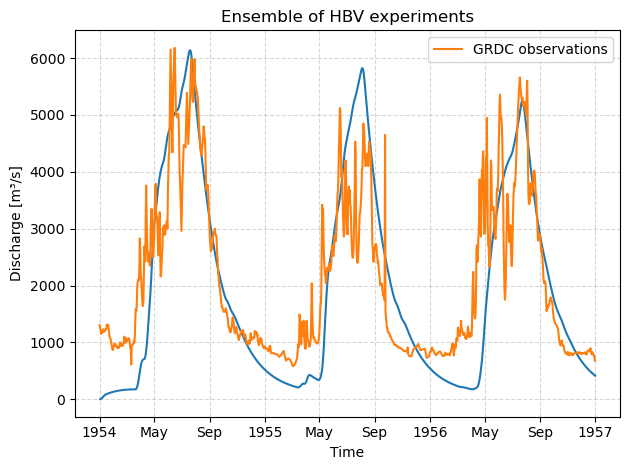

In [22]:
plt.plot(
    discharge_1955_m3.time,
    discharge_1955_m3.isel(particle=74),
)


# plot GRDC
max_y = 2 * ds["streamflow"].max()
ds["streamflow"].plot(label="GRDC observations")

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [53]:
import hydrostats as hs
import hydrostats.analyze as ha
import pandas as pd
from hydrostats.metrics import dr, kge_2009, kge_2012, nse, nse_mod, nse_rel

# converteer naar DataFrame
df = pd.DataFrame(
    {
        "obs": ds["streamflow"].values[:1095],
        "sim": discharge_1955_m3.isel(particle=74).values[:1095],
    },
    index=ds["streamflow"].time[:1095],
)  # als je tijd hebt als index

# merge_data kan dan gebruikt worden met DataFrames
merged_df = hs.data.merge_data(sim_df=df["sim"], obs_df=df["obs"], column_names=("sim", "obs"))

In [54]:
merged_df

,sim,obs
1954-01-01,0.729721,1300.0
1954-01-02,2.964316,1260.0
1954-01-03,6.793671,1220.0
1954-01-04,12.305789,1190.0
1954-01-05,19.586916,1150.0
...,...,...
1956-12-26,438.469065,811.0
1956-12-27,431.702162,792.0
1956-12-28,425.057368,772.0
1956-12-29,418.532413,772.0


/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/hydrostats/analyze.py:359: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


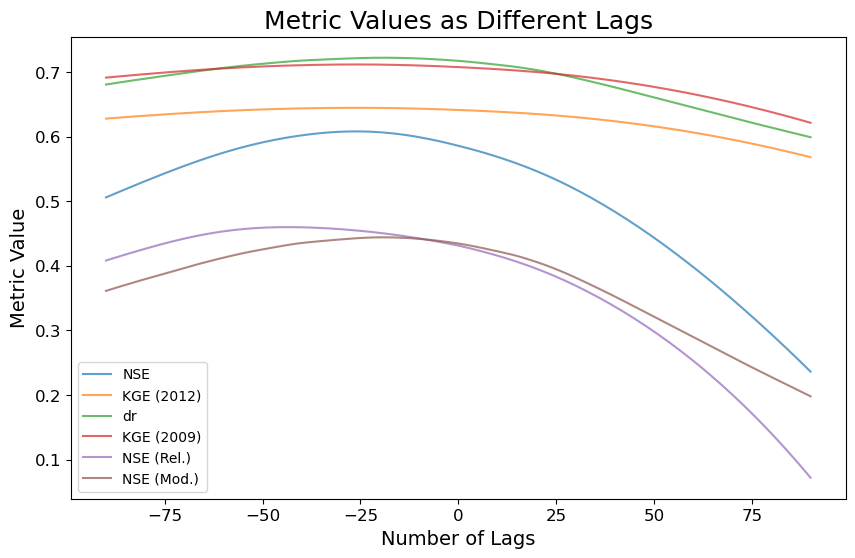

In [59]:
# maak de time-lag plot
_ = ha.time_lag(
    merged_df,
    shift_range=(-90, 90),
    metrics=[nse.abbr, kge_2012.abbr, dr.abbr, kge_2009.abbr, nse_rel.abbr, nse_mod.abbr],
    plot=True,
)

In [65]:
time_lag_df, summary_df = ha.time_lag(
    merged_df,
    shift_range=(-90, 90),
    metrics=[nse.abbr, kge_2012.abbr, dr.abbr, kge_2009.abbr, nse_rel.abbr, nse_mod.abbr],
)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/hydrostats/analyze.py:359: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.


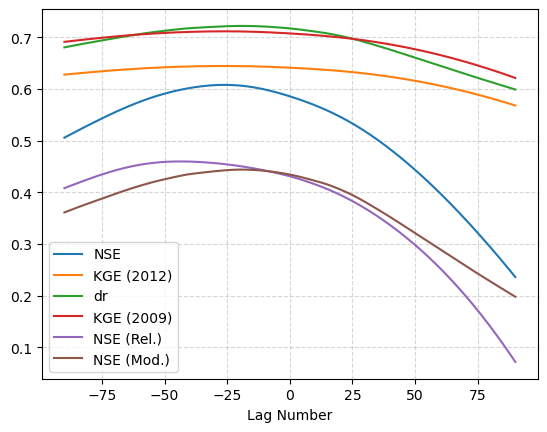

In [68]:
time_lag_df.plot()
plt.grid(linestyle="--", alpha=0.5)